In [ ]:
# Cell 1

# Import core Python libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import re
import string

# Import machine learning and preprocessing tools from scikit-learn
from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report, confusion_matrix
from sklearn.preprocessing import LabelEncoder

# Import NLTK libraries for text processing
import nltk
from nltk.corpus import stopwords
from nltk.stem import WordNetLemmatizer

# Download required NLTK datasets for stopwords and lemmatization
nltk.download('stopwords')
nltk.download('wordnet')


[nltk_data] Downloading package stopwords to
[nltk_data]     C:\Users\Admin\AppData\Roaming\nltk_data...
[nltk_data]   Package stopwords is already up-to-date!
[nltk_data] Downloading package wordnet to
[nltk_data]     C:\Users\Admin\AppData\Roaming\nltk_data...
[nltk_data]   Package wordnet is already up-to-date!


True

In [ ]:
# Cell 2 

# Load the dataset from the 'Tweets.csv' file
df = pd.read_csv("data/Tweets.csv")

# Display the shape (rows, columns) and the column names of the DataFrame
df.shape, df.columns


((14640, 15),
 Index(['tweet_id', 'airline_sentiment', 'airline_sentiment_confidence',
        'negativereason', 'negativereason_confidence', 'airline',
        'airline_sentiment_gold', 'name', 'negativereason_gold',
        'retweet_count', 'text', 'tweet_coord', 'tweet_created',
        'tweet_location', 'user_timezone'],
       dtype='object'))

In [12]:
# Cell 3

# Display a random sample of 5 rows with only the 'text', 'airline', and 'airline_sentiment' columns
df[['text', 'airline', 'airline_sentiment']].sample(5)


,text,airline,airline_sentiment
6697,@SouthwestAir Trying to get through by phone t...,Southwest,negative
6503,@SouthwestAir extremely #disappointed with poo...,Southwest,negative
1333,@united someone should send a note to the reve...,United,neutral
4065,@united ooh thanks!,United,positive
11705,@USAirways Thank you. And thanks for being so ...,US Airways,positive


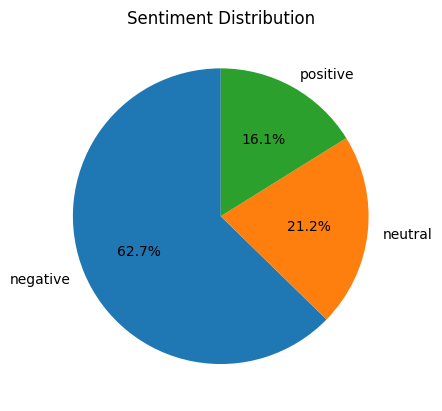

In [ ]:
# Cell 4

# Plot the distribution of airline sentiments as a pie chart
df['airline_sentiment'].value_counts().plot(kind='pie', autopct='%1.1f%%', startangle=90)

# Set chart title and remove y-axis label
plt.title("Sentiment Distribution")
plt.ylabel("")

# Display the pie chart
plt.show()



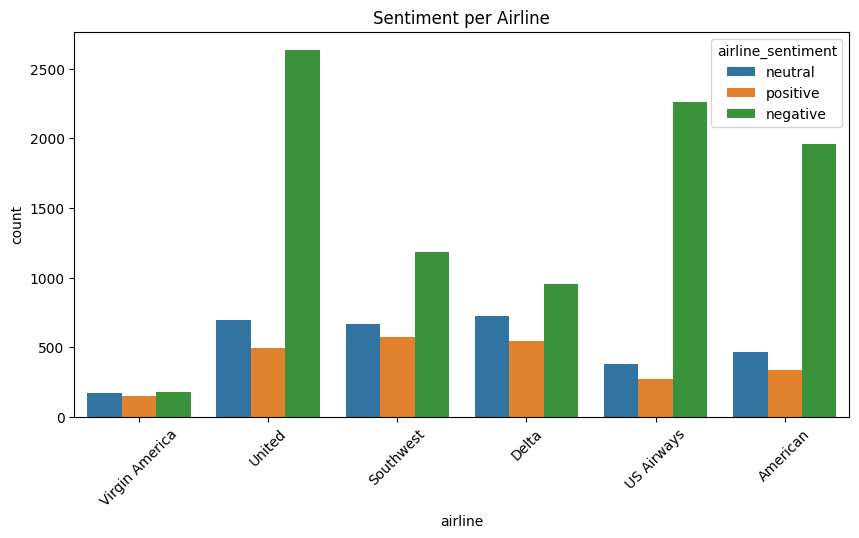

In [ ]:
# Cell 5

# Set the figure size for the plot
plt.figure(figsize=(10, 5))

# Create a count plot showing sentiment distribution per airline
sns.countplot(data=df, x='airline', hue='airline_sentiment')

# Set the title of the chart
plt.title("Sentiment per Airline")

# Rotate x-axis labels for better readability
plt.xticks(rotation=45)

# Display the plot
plt.show()


In [ ]:
# Cell 6

# Load English stopwords
stop_words = set(stopwords.words('english'))

# Initialize the WordNet lemmatizer
lemmatizer = WordNetLemmatizer()

# Define a function to clean tweet text
def clean_text(text):
    text = text.lower()  # convert to lowercase
    text = re.sub(r'http\S+|www\S+', '', text)  # remove URLs
    text = re.sub(r'@\w+|#\w+', '', text)       # remove mentions and hashtags
    text = re.sub(r'[^a-zA-Z\s]', '', text)     # remove special characters and numbers
    text = ' '.join([lemmatizer.lemmatize(word) 
                     for word in text.split() 
                     if word not in stop_words])  # lemmatize and remove stopwords
    return text

# Apply the cleaning function to the 'text' column and store it in a new column
df['clean_text'] = df['text'].apply(clean_text)

# Display original and cleaned text for first few rows
df[['text', 'clean_text']].head()


,text,clean_text
0,@VirginAmerica What @dhepburn said.,said
1,@VirginAmerica plus you've added commercials t...,plus youve added commercial experience tacky
2,@VirginAmerica I didn't today... Must mean I n...,didnt today must mean need take another trip
3,@VirginAmerica it's really aggressive to blast...,really aggressive blast obnoxious entertainmen...
4,@VirginAmerica and it's a really big bad thing...,really big bad thing


In [ ]:
# Cell 7

# Initialize label encoder
le = LabelEncoder()

# Encode sentiment labels into numeric form (e.g., 0 = negative, 1 = neutral, 2 = positive)
df['label'] = le.fit_transform(df['airline_sentiment'])

# Show unique combinations of original sentiment and encoded label
df[['airline_sentiment', 'label']].drop_duplicates()


,airline_sentiment,label
0,neutral,1
1,positive,2
3,negative,0


In [13]:
# Cell 8

# Initialize TF-IDF Vectorizer with a maximum of 3000 features
tfidf = TfidfVectorizer(max_features=3000)

# Transform the cleaned text into TF-IDF feature vectors
X = tfidf.fit_transform(df['clean_text']).toarray()

# Set target variable (sentiment label)
y = df['label']


In [14]:
# Cell 9

# Split the data into training and testing sets (80% train, 20% test)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Initialize a Logistic Regression model with increased iteration limit
model = LogisticRegression(max_iter=1000)

# Train the model on the training data
model.fit(X_train, y_train)


,penalty,'l2'
,dual,False
,tol,0.0001
,C,1.0
,fit_intercept,True
,intercept_scaling,1
,class_weight,None
,random_state,None
,solver,'lbfgs'
,max_iter,1000
,multi_class,'deprecated'


Classification Report:
              precision    recall  f1-score   support

    negative       0.82      0.94      0.88      1889
     neutral       0.66      0.49      0.56       580
    positive       0.82      0.61      0.70       459

    accuracy                           0.80      2928
   macro avg       0.77      0.68      0.71      2928
weighted avg       0.79      0.80      0.79      2928



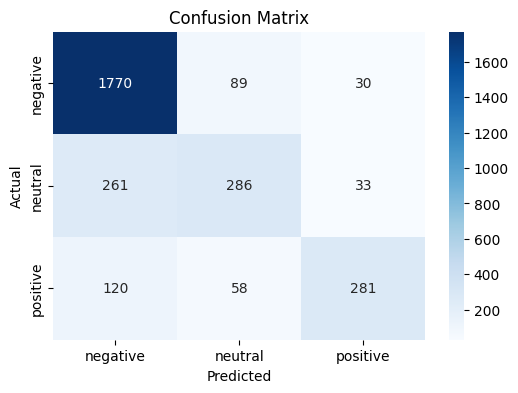

In [ ]:
# Cell 10

# Predict sentiment labels for the test set
y_pred = model.predict(X_test)

# Print classification report with precision, recall, and F1-score
print("Classification Report:")
print(classification_report(y_test, y_pred, target_names=le.classes_))

# Confusion Matrix
plt.figure(figsize=(6, 4))
sns.heatmap(confusion_matrix(y_test, y_pred), annot=True, fmt='d', cmap='Blues',
            xticklabels=le.classes_, yticklabels=le.classes_)  # Show class labels on axes
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix")
plt.show()


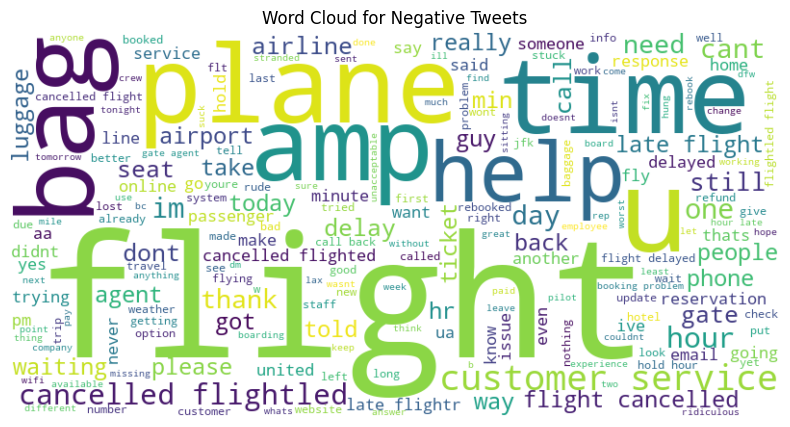

In [ ]:
# Cell 11

# Import WordCloud for visualization
from wordcloud import WordCloud

# Filter only negative tweets and extract their cleaned text
neg_tweets = df[df['airline_sentiment'] == 'negative']['clean_text']

# Combine all negative tweets into a single string
neg_text_combined = ' '.join(neg_tweets)

# Generate a word cloud from the combined text
wordcloud = WordCloud(width=800, height=400, background_color='white').generate(neg_text_combined)

# Plot the word cloud
plt.figure(figsize=(10, 5))
plt.imshow(wordcloud, interpolation='bilinear')
plt.axis('off')
plt.title('Word Cloud for Negative Tweets')
plt.show()
